# Описание

Конспект курса по А/Б-тестам Глеба Михайлова

## Метрики

| Метрика | Расшифровка | Формула | Альтернативная запись | Ошибка? |
|---|---|---|---|---|
| **TPR** | True Positive Rate | TP / (TP + FN) | TP / P | — |
| **TNR** | True Negative Rate | TN / (TN + FP) | TN / N | — |
| **FPR** | False Positive Rate | FP / (FP + TN) | FP / N | **Ошибка I рода (α)** |
| **FNR** | False Negative Rate | FN / (TP + FN) | FN / P | **Ошибка II рода (β)** |

------
где **P** = все фактические положительные (TP + FN),

**N** = все фактические отрицательные (FP + TN)

------

**Accuracy** - % правильных ответов, без разницы между группами (т.е. мы не разделяем, где мы ошиблись — на больных или на здоровых)

**Accuracy для TPR** - Sensitivity (чувствительность) - ошибка II рода

**Accuracy для TNR** - Specificity (специфичность) - ошибка I рода

# Задача

- Проанализировать два теста и решить какой из них лучше

# Загрузка данных

In [ ]:
import pandas as pd

In [ ]:
! pip install gdown==v4.6.3

In [ ]:
! gdown 1QqWhauAgV8PQV-bLNyHnDjVV2sLFq9UA

Downloading...
From: https://drive.google.com/uc?id=1QqWhauAgV8PQV-bLNyHnDjVV2sLFq9UA
To: /content/covid.csv
100% 60.0k/60.0k [00:00<00:00, 18.1MB/s]


In [ ]:
df = pd.read_csv('/content/covid.csv')

In [ ]:
len(df)

10000

In [ ]:
df.head()

,y_true,y_pred1,y_pred2
0,0,0,0
1,1,1,0
2,1,0,1
3,0,1,0
4,1,0,1


# Структура данных

- y_true - реальные данные:
  - 0 - здоров
  - 1 - болен
- y_pred1 - результат работы первого теста
- y_pred2 - результат второго теста

## Подсчет процента ошибок

## Первый тест

In [ ]:
# выводим все строки, где есть ошибки в первом тесте и счаитем их кол-во
len(df[df['y_true'] != df['y_pred1']])

1800

In [ ]:
# выводим процент ошибок первого теста
print(f'Процент ошибок первого теста: {len(df[df['y_true'] != df['y_pred1']]) / len(df):.0%}')

Процент ошибок первого теста: 18%


In [ ]:
# второй вариант подсчета методом mean()
(df['y_true'] != df['y_pred1']).mean()

np.float64(0.18)

## Второй тест

In [ ]:
print(f'Процент ошибок второго теста: {len(df[df['y_true'] != df['y_pred2']]) / len(df):.0%}')

Процент ошибок второго теста: 18%


In [ ]:
# второй вариант подсчета методом mean()
(df['y_true'] != df['y_pred2']).mean()

np.float64(0.18)

## Accuracy (1 - % ошибок)

In [ ]:
# 1 вариант (ручной подсчет)
(df['y_true'] == df['y_pred2']).mean()

np.float64(0.82)

In [ ]:
# подсчет с помощью встроенных библиотек и методов
# на вход берутся правильные ответы и ответы теста

from sklearn.metrics import accuracy_score

In [ ]:
# Accuracy для первого теста
accuracy_score(df['y_true'], df['y_pred1'])

0.82

In [ ]:
# Accuracy для творого теста
accuracy_score(df['y_true'], df['y_pred2'])

0.82

## Positive & Negative (смотрим на здоровых и больных отдельно)

In [ ]:
positives = df.query('y_true == 1').copy()
positives.head()

,y_true,y_pred1,y_pred2
1,1,1,0
2,1,0,1
4,1,0,1
5,1,1,1
6,1,1,1


In [ ]:
negatives = df[df['y_true'] == 0].copy()
#negatives.head()

### FNR

In [ ]:
# процент ошибок на больных (positives) для первого теста
round((positives['y_true'] != positives['y_pred1']).mean(), 2)
print(f'В {(positives['y_true'] != positives['y_pred1']).mean():.0%} случаев "пропускаем" больного.\nВыборка состоит из больных, и результат показывает процент ошибки теста, когда тест не показал больного больным.')

В 29% случаев "пропускаем" больного.
Выборка состоит из больных, и результат показывает процент ошибки теста, когда тест не показал больного больным.


In [ ]:
# процент ошибок на больных (positives) для творого теста
round((positives['y_true'] != positives['y_pred2']).mean(), 2)

np.float64(0.34)

### FPR

In [ ]:
round((negatives['y_true'] != negatives['y_pred1']).mean(), 2)
print(f'Процент ошибок на здоровых для первого теста: {(negatives['y_true'] != negatives['y_pred1']).mean():.0%}')

Процент ошибок на здоровых для первого теста: 6%


In [ ]:
round((negatives['y_true'] != negatives['y_pred2']).mean(), 2)
print(f'Процент ошибок на здоровых для второго теста: {(negatives['y_true'] != negatives['y_pred2']).mean():.0%}')

Процент ошибок на здоровых для второго теста: 1%


## Sensitivity

In [ ]:
# для первого теста
round(accuracy_score(positives['y_true'], positives['y_pred1']), 2)

0.71

In [ ]:
# для второго теста
round(accuracy_score(positives['y_true'], positives['y_pred2']), 2)

0.66

## Specificity

In [ ]:
# для первого теста
round(accuracy_score(negatives['y_true'], negatives['y_pred1']), 2)

0.94

In [ ]:
# для второго теста
round(accuracy_score(negatives['y_true'], negatives['y_pred2']), 2)

0.99

## Sensitivity & Specificity as functions
(подсчет sensetivity и specifisity с помощью функции, без разбивки датафрейма на отдельные случаи)

In [ ]:
from sklearn.metrics import recall_score # (<--- по умолчанию sensitivity)

In [ ]:
# sensitivity для первого теста
recall_score(df['y_true'], df['y_pred1'])

0.7050147492625368

In [ ]:
# sensitivity для второго теста
recall_score(df['y_true'], df['y_pred2'])

0.655850540806293

In [ ]:
# specificity для первого теста
recall_score(df['y_true'], df['y_pred1'], pos_label=0)

0.9389623601220752

In [ ]:
# specificity для второго теста
recall_score(df['y_true'], df['y_pred2'], pos_label=0)

0.9898270600203459

## Confusion matrix (матрица ошибок)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# матрица ошибок для первого теста
cm = confusion_matrix(df['y_true'], df['y_pred1'])

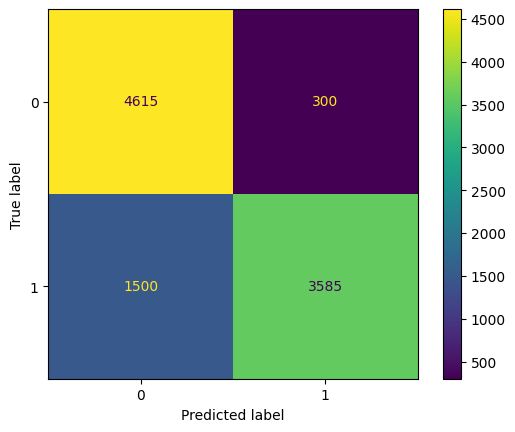

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

 - **True label** - реальность
 - **Predicted label** - ответ теста на ковид

In [ ]:
# матрица ошибок для второго теста
cm = confusion_matrix(df['y_true'], df['y_pred2'])

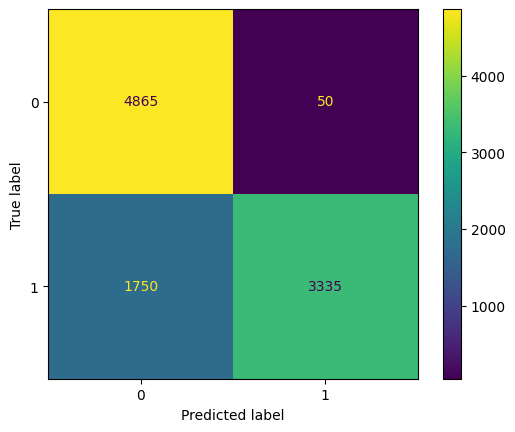

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
confusion_matrix(df['y_true'], df['y_pred2'])

array([[4865,   50],
       [1750, 3335]])

In [ ]:
tn, fp, fn, tp = confusion_matrix(df['y_true'], df['y_pred2']).ravel()

In [ ]:
tn, fp, fn, tp

(np.int64(4865), np.int64(50), np.int64(1750), np.int64(3335))

In [ ]:
# Sensitivity
tp / (tp + fn)

np.float64(0.655850540806293)